# 🎨 EmojiBlend — Variational Autoencoder for Emoji Fusion
**Team PPG | Mini Project | TensorFlow/Keras**

This notebook trains a **Convolutional VAE from scratch** on the OpenMoji dataset.
The goal is to learn a smooth latent space so we can **interpolate between two emojis** and generate novel blended outputs.

### Pipeline Overview
1. Download OpenMoji 72x72 PNG dataset
2. Preprocess (RGBA → RGB, normalize)
3. Build Convolutional VAE from scratch
4. Train with Reconstruction + KL + Perceptual Loss
5. Save encoder/decoder weights
6. Demo: blend two emojis via latent interpolation

In [1]:
# ── 0. Install dependencies ──────────────────────────────────────────────────
!pip install -q tensorflow pillow numpy matplotlib requests tqdm

In [2]:
# ── 1. Imports ───────────────────────────────────────────────────────────────
import os, io, zipfile, json, math, requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.21.0
GPU available: False


In [3]:
# ── 2. Config ────────────────────────────────────────────────────────────────
IMG_SIZE    = 72          # OpenMoji native size
LATENT_DIM  = 256         # Higher = sharper latent space
BATCH_SIZE  = 64
EPOCHS      = 80
LR          = 1e-3
KL_WEIGHT   = 0.0005      # Low KL weight = sharper reconstructions
DATA_DIR    = Path("openmoji_data")
CKPT_DIR    = Path("checkpoints")
CKPT_DIR.mkdir(exist_ok=True)

In [4]:
# ── 3. Download OpenMoji Dataset ─────────────────────────────────────────────
# OpenMoji: open-source, CC BY-SA 4.0 license
# 3,000+ emojis in clean 72x72 PNG format

ZIP_URL = "https://github.com/hfg-gmuend/openmoji/releases/latest/download/openmoji-72x72-color.zip"
ZIP_PATH = Path("openmoji-72x72-color.zip")

if not DATA_DIR.exists():
    print("Downloading OpenMoji dataset...")
    r = requests.get(ZIP_URL, stream=True)
    total = int(r.headers.get('content-length', 0))
    with open(ZIP_PATH, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as bar:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
            bar.update(len(chunk))
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    ZIP_PATH.unlink()
    print(f"Done! Files extracted to {DATA_DIR}")
else:
    print(f"Dataset already downloaded at {DATA_DIR}")

all_png = list(DATA_DIR.rglob("*.png"))
print(f"Total emoji images found: {len(all_png)}")

Dataset already downloaded at openmoji_data
Total emoji images found: 4495


In [5]:
# ── 4. Load & Preprocess Dataset ─────────────────────────────────────────────
# Composites RGBA onto white background for clean RGB training

def load_emoji(path, size=IMG_SIZE):
    """Load a PNG with transparency, composite on white, return float32 RGB [0,1]."""
    img = Image.open(path).convert("RGBA").resize((size, size), Image.LANCZOS)
    bg  = Image.new("RGBA", img.size, (255, 255, 255, 255))
    bg.paste(img, mask=img.split()[3])   # Alpha compositing
    rgb = bg.convert("RGB")
    return np.array(rgb, dtype=np.float32) / 255.0

print("Loading and preprocessing emoji images...")
images = []
paths  = []
for p in tqdm(all_png):
    try:
        img = load_emoji(p)
        images.append(img)
        paths.append(p)
    except Exception:
        pass

images = np.array(images, dtype=np.float32)
print(f"Dataset shape: {images.shape}")

# Build name lookup: hex code -> path
emoji_lookup = {p.stem: p for p in paths}

Loading and preprocessing emoji images...


100%|██████████| 4495/4495 [00:00<00:00, 5143.49it/s]


Dataset shape: (4495, 72, 72, 3)


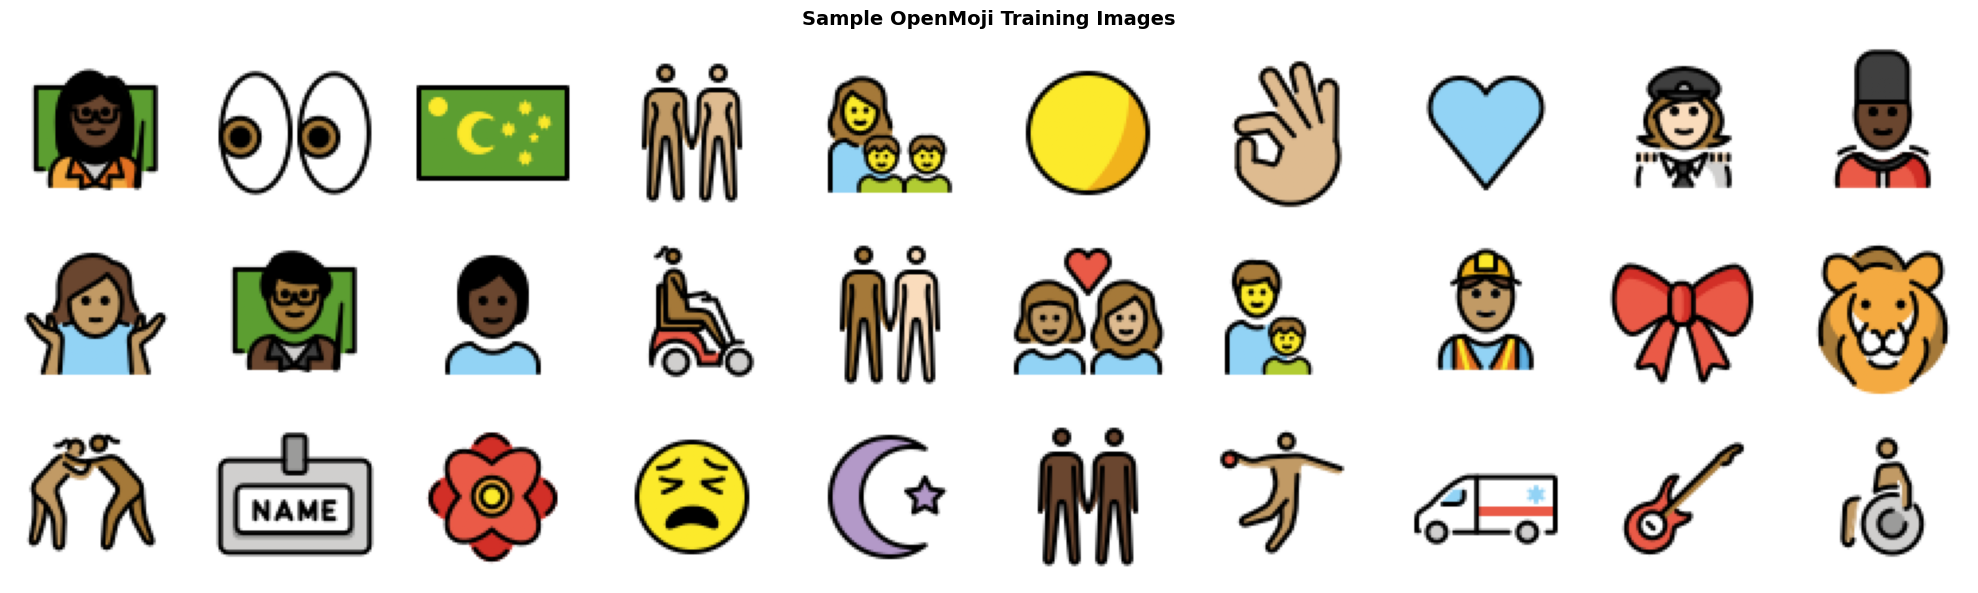

In [6]:
# ── 5. Quick Dataset Preview ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 10, figsize=(20, 6))
idxs = np.random.choice(len(images), 30, replace=False)
for ax, i in zip(axes.flat, idxs):
    ax.imshow(images[i])
    ax.axis("off")
plt.suptitle("Sample OpenMoji Training Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("dataset_preview.png", dpi=100)
plt.show()

In [7]:
# ── 6. tf.data Pipeline ──────────────────────────────────────────────────────
def augment(img):
    """Light augmentation — flip only, no color jitter (breaks emoji semantics)."""
    img = tf.image.random_flip_left_right(img)
    return img

dataset = tf.data.Dataset.from_tensor_slices(images)
dataset = dataset.shuffle(len(images), seed=42)
dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Batches per epoch: {len(dataset)}")

Batches per epoch: 71


In [8]:
# ── 7. Sampling Layer ────────────────────────────────────────────────────────
class Sampling(layers.Layer):
    """Reparameterization trick: z = mu + eps * sigma."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

In [9]:
# ── 8. Encoder ───────────────────────────────────────────────────────────────
# Deep conv encoder: 72x72x3 → latent vector of LATENT_DIM

def build_encoder(latent_dim=LATENT_DIM):
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="encoder_input")

    # Block 1: 72 → 36
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Block 2: 36 → 18
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Block 3: 18 → 9
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Block 4: 9 → 9 (deepen without downsampling — keeps spatial 9x9 for clean decoder mirror)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)  # NO stride — stays 9x9
    x = layers.BatchNormalization()(x)

    # GlobalAveragePooling instead of Flatten: avoids 9*9*256=20736 giant vector → NaN
    x = layers.GlobalAveragePooling2D()(x)  # → (batch, 256)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    z_mean    = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z         = Sampling(name="z")([z_mean, z_log_var])

    return keras.Model(inp, [z_mean, z_log_var, z], name="encoder")

encoder = build_encoder()
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 72, 72, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 72, 72,    │        896 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 72, 72,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 36, 36,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 36,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 36, 36,    │     18,496 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 36,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 18, 18,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 18,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 18, 18,    │     73,856 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 18,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 9, 9, 128) │    147,584 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9, 9, 128) │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 9, 9, 256) │    295,168 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9, 9, 256) │      1,024 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 9, 9, 256) │    590,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9, 9, 256) │      1,024 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ batch_normalizat

 Total params: 1,570,336 (5.99 MB)

 Trainable params: 1,568,416 (5.98 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [10]:
# ── 9. Decoder ───────────────────────────────────────────────────────────────
# Mirror of encoder: latent_dim → 72x72x3
# Spatial chain: 9 → 18 → 36 → 72  (3 stride-2 transposes, perfectly mirrors encoder)

def build_decoder(latent_dim=LATENT_DIM):
    inp = keras.Input(shape=(latent_dim,), name="decoder_input")

    # Project back to 9x9 spatial (mirrors encoder's 9x9 feature map)
    x = layers.Dense(9 * 9 * 256, activation="relu")(inp)
    x = layers.Reshape((9, 9, 256))(x)

    # Deepen at 9x9 (mirrors encoder Block 4 without downsampling)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Upsample: 9 → 18
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Upsample: 18 → 36
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Upsample: 36 → 72
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Refine at 72x72
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)

    # Output: sigmoid → [0,1], shape guaranteed 72x72x3
    out = layers.Conv2D(3, 3, padding="same", activation="sigmoid", name="output")(x)

    return keras.Model(inp, out, name="decoder")

decoder = build_decoder()
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20736)          │     5,329,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 9, 9, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 9, 9, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 18, 18, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 36, 36, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 36, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 72, 72, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 72, 72, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 72, 72, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 72, 72, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,318,563 (24.10 MB)

 Trainable params: 6,317,603 (24.10 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
# ── 10. VAE Model ────────────────────────────────────────────────────────────

class EmojiVAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight=KL_WEIGHT, **kwargs):
        super().__init__(**kwargs)
        self.encoder   = encoder
        self.decoder   = decoder
        self.kl_weight = kl_weight

        # Metrics
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker    = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data, training=True)
            reconstruction       = self.decoder(z, training=True)

            # Reconstruction loss (MSE per pixel, then sum over spatial dims)
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction), axis=[1, 2, 3])
            )

            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )

            total_loss = recon_loss + self.kl_weight * kl_loss

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

In [12]:
# ── 11. Callbacks ────────────────────────────────────────────────────────────

class VisualCallback(keras.callbacks.Callback):
    """Visualize reconstructions + interpolations every N epochs."""
    def __init__(self, val_images, every_n=10):
        super().__init__()
        self.val  = val_images[:8]
        self.n    = every_n

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.n != 0:
            return
        z_mean, _, _ = self.model.encoder.predict(self.val, verbose=0)
        recons       = self.model.decoder.predict(z_mean, verbose=0)

        fig, axes = plt.subplots(2, 8, figsize=(20, 5))
        for i in range(8):
            axes[0, i].imshow(self.val[i])
            axes[0, i].axis("off")
            axes[0, i].set_title("Original", fontsize=8)
            axes[1, i].imshow(np.clip(recons[i], 0, 1))
            axes[1, i].axis("off")
            axes[1, i].set_title("Recon", fontsize=8)
        plt.suptitle(f"Epoch {epoch+1} — Reconstructions", fontsize=12)
        plt.tight_layout()
        plt.savefig(f"recon_epoch_{epoch+1:03d}.png", dpi=80)
        plt.show()


# Sample 8 images for validation
val_imgs = images[np.random.choice(len(images), 8, replace=False)]

VAE built. Encoder params: 1,570,336 | Decoder params: 6,318,563
Output shape check passed: (2, 72, 72, 3)  ✓
Epoch 1/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - kl_loss: 124.2230 - loss: 1465.0040 - recon_loss: 1464.9419
Epoch 1: loss improved from None to 1122.77808, saving model to checkpoints/vae_best.weights.h5

Epoch 1: finished saving model to checkpoints/vae_best.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 48s 601ms/step - kl_loss: 199.6645 - loss: 1122.7781 - recon_loss: 1122.6781
Epoch 2/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - kl_loss: 274.6330 - loss: 865.6144 - recon_loss: 865.4771
Epoch 2: loss improved from 1122.77808 to 831.52747, saving model to checkpoints/vae_best.weights.h5

Epoch 2: finished saving model to checkpoints/vae_best.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 562ms/step - kl_loss: 305.5324 - loss: 831.5275 - recon_loss: 831.3747
Epoch 3/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - kl_loss: 398.2063 - loss: 734.4853 - recon_loss: 734.2862
Epoch 3: loss i

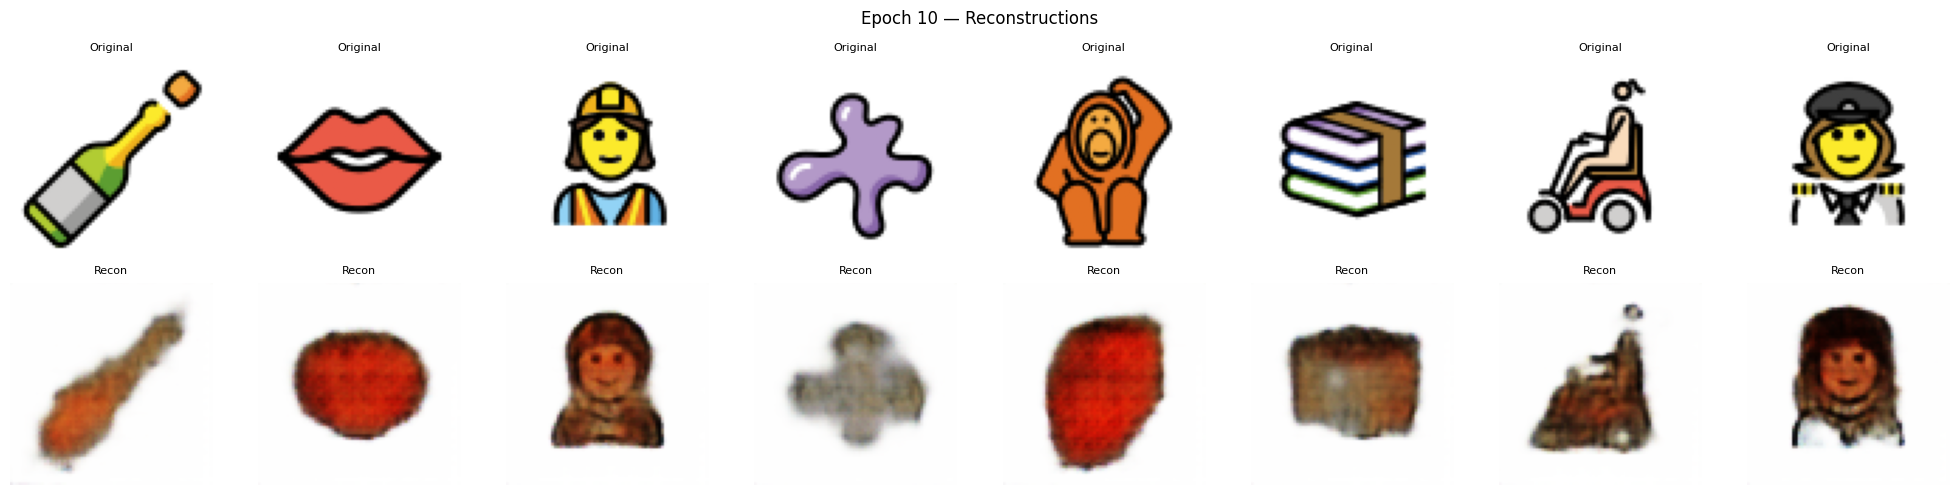

71/71 ━━━━━━━━━━━━━━━━━━━━ 47s 666ms/step - kl_loss: 758.4859 - loss: 442.0828 - recon_loss: 441.7036
Epoch 11/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - kl_loss: 790.4932 - loss: 414.0176 - recon_loss: 413.6224
Epoch 11: loss improved from 442.08282 to 416.48062, saving model to checkpoints/vae_best.weights.h5

Epoch 11: finished saving model to checkpoints/vae_best.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 43s 605ms/step - kl_loss: 794.4174 - loss: 416.4806 - recon_loss: 416.0834
Epoch 12/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - kl_loss: 815.7182 - loss: 399.3196 - recon_loss: 398.9117
Epoch 12: loss improved from 416.48062 to 398.29340, saving model to checkpoints/vae_best.weights.h5

Epoch 12: finished saving model to checkpoints/vae_best.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 44s 609ms/step - kl_loss: 828.9170 - loss: 398.2934 - recon_loss: 397.8789
Epoch 13/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - kl_loss: 842.3497 - loss: 387.9122 - recon_loss: 387.4911
Epoch 13: loss im

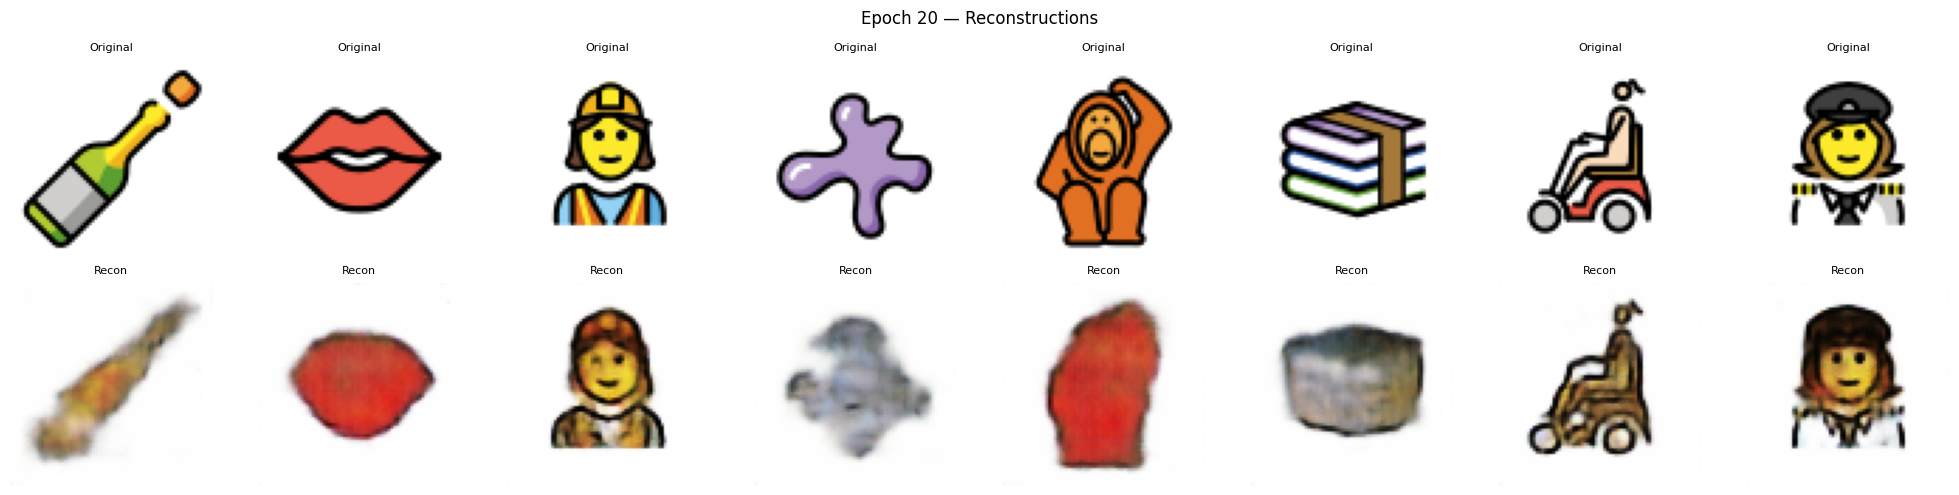

71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 569ms/step - kl_loss: 926.8317 - loss: 308.3840 - recon_loss: 307.9206
Epoch 21/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - kl_loss: 932.8591 - loss: 298.3778 - recon_loss: 297.9114
Epoch 21: loss improved from 308.38400 to 296.83536, saving model to checkpoints/vae_best.weights.h5

Epoch 21: finished saving model to checkpoints/vae_best.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 44s 621ms/step - kl_loss: 934.5015 - loss: 296.8354 - recon_loss: 296.3680
Epoch 22/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - kl_loss: 927.5126 - loss: 289.7808 - recon_loss: 289.3171
Epoch 22: loss improved from 296.83536 to 292.52020, saving model to checkpoints/vae_best.weights.h5

Epoch 22: finished saving model to checkpoints/vae_best.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 579ms/step - kl_loss: 931.9081 - loss: 292.5202 - recon_loss: 292.0542
Epoch 23/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - kl_loss: 941.0554 - loss: 280.0053 - recon_loss: 279.5348
Epoch 23: loss im

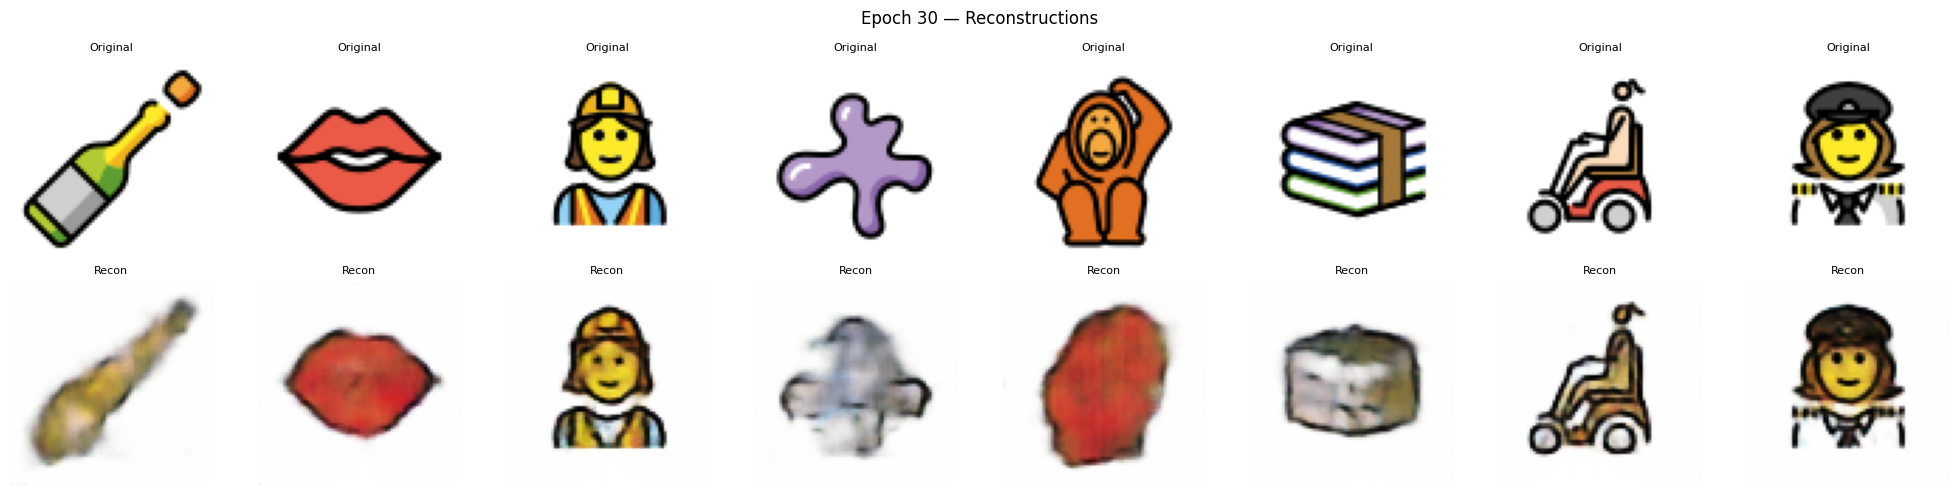

71/71 ━━━━━━━━━━━━━━━━━━━━ 38s 532ms/step - kl_loss: 959.5647 - loss: 240.3442 - recon_loss: 239.8645
Epoch 31/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - kl_loss: 949.1164 - loss: 232.2938 - recon_loss: 231.8192
Epoch 31: loss improved from 240.34424 to 235.42232, saving model to checkpoints/vae_best.weights.h5

Epoch 31: finished saving model to checkpoints/vae_best.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 38s 532ms/step - kl_loss: 950.6978 - loss: 235.4223 - recon_loss: 234.9470
Epoch 32/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - kl_loss: 965.1413 - loss: 230.6592 - recon_loss: 230.1766
Epoch 32: loss improved from 235.42232 to 231.81322, saving model to checkpoints/vae_best.weights.h5

Epoch 32: finished saving model to checkpoints/vae_best.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 37s 525ms/step - kl_loss: 966.1324 - loss: 231.8132 - recon_loss: 231.3302
Epoch 33/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - kl_loss: 961.7431 - loss: 222.4743 - recon_loss: 221.9935
Epoch 33: loss im

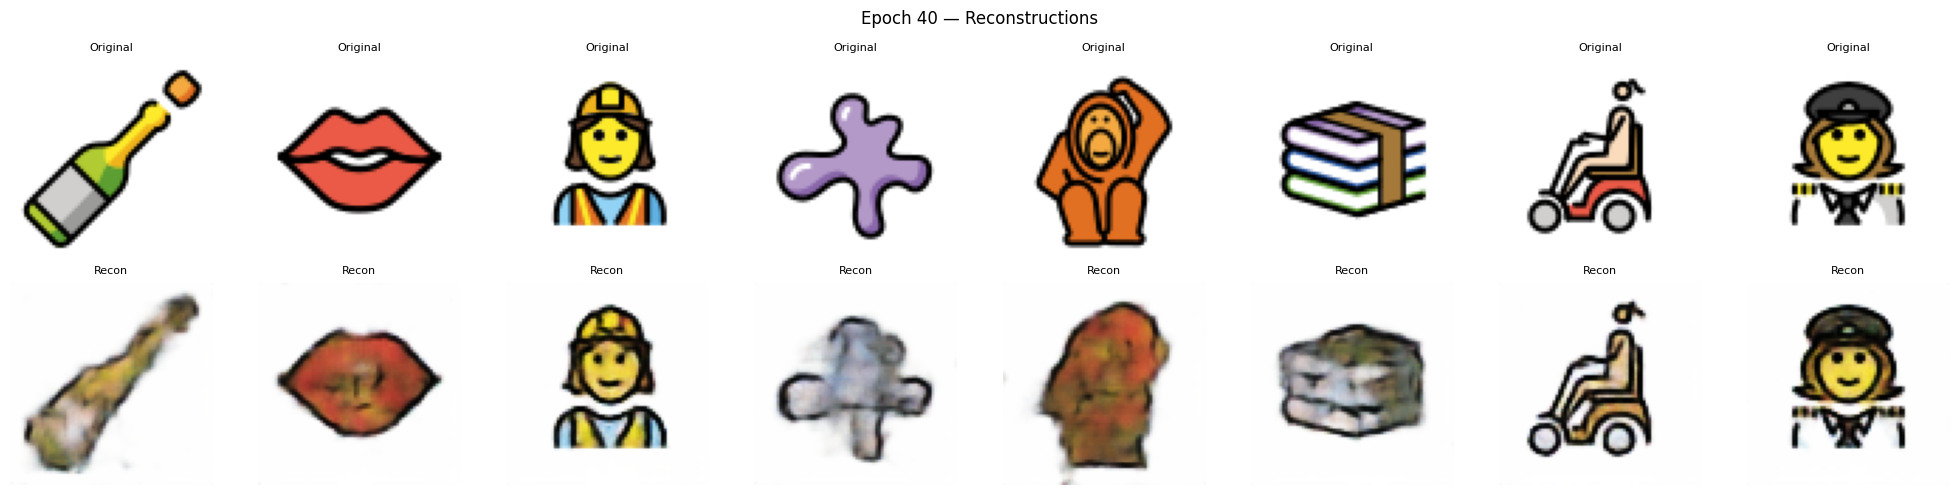

71/71 ━━━━━━━━━━━━━━━━━━━━ 345s 5s/step - kl_loss: 965.0144 - loss: 197.8698 - recon_loss: 197.3873
Epoch 41/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - kl_loss: 970.6824 - loss: 190.3834 - recon_loss: 189.8981
Epoch 41: loss improved from 197.86975 to 195.49446, saving model to checkpoints/vae_best.weights.h5

Epoch 41: finished saving model to checkpoints/vae_best.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 37s 514ms/step - kl_loss: 971.8948 - loss: 195.4945 - recon_loss: 195.0085
Epoch 42/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - kl_loss: 972.2634 - loss: 192.4934 - recon_loss: 192.0073
Epoch 42: loss improved from 195.49446 to 191.63040, saving model to checkpoints/vae_best.weights.h5

Epoch 42: finished saving model to checkpoints/vae_best.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 36s 514ms/step - kl_loss: 972.3925 - loss: 191.6304 - recon_loss: 191.1442
Epoch 43/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - kl_loss: 971.4438 - loss: 192.4295 - recon_loss: 191.9438 
Epoch 43: loss impro

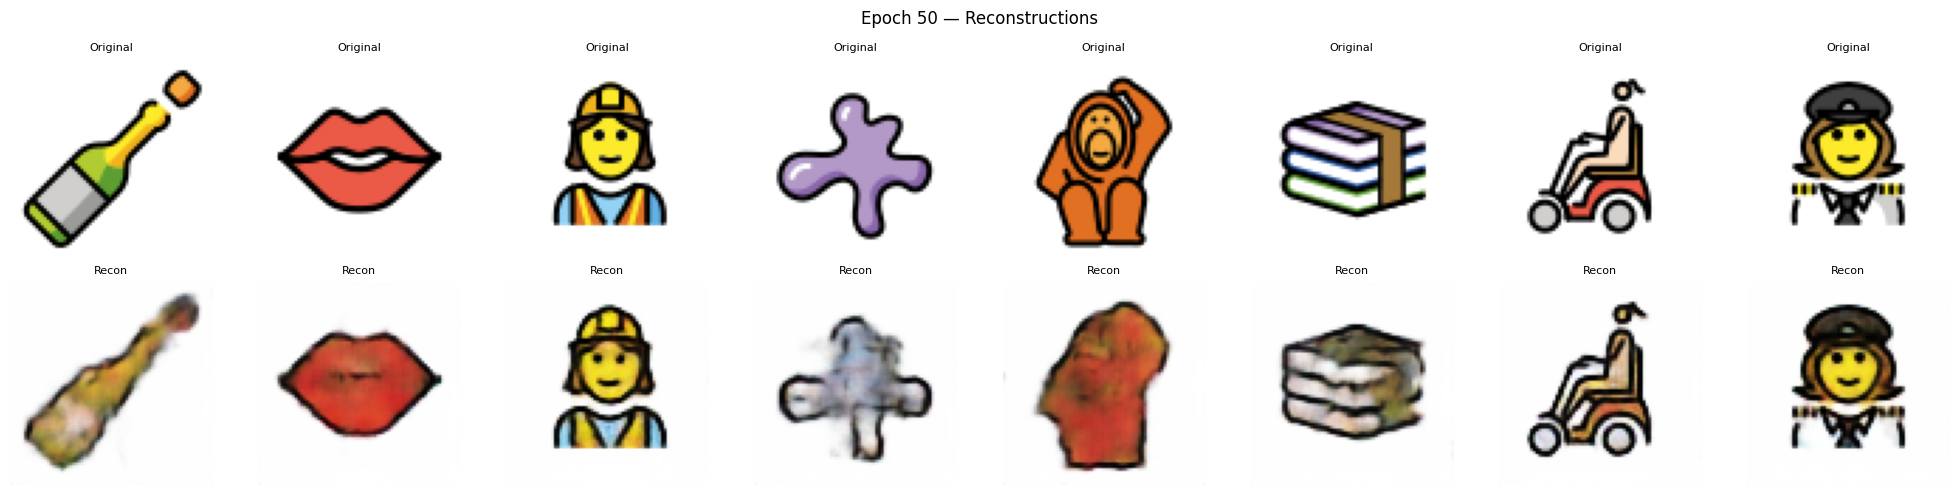

71/71 ━━━━━━━━━━━━━━━━━━━━ 38s 530ms/step - kl_loss: 961.8511 - loss: 166.1520 - recon_loss: 165.6710
Epoch 51/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - kl_loss: 955.2456 - loss: 164.3945 - recon_loss: 163.9169
Epoch 51: loss improved from 166.15196 to 164.30585, saving model to checkpoints/vae_best.weights.h5

Epoch 51: finished saving model to checkpoints/vae_best.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 37s 520ms/step - kl_loss: 950.7962 - loss: 164.3058 - recon_loss: 163.8305
Epoch 52/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - kl_loss: 955.4523 - loss: 158.6777 - recon_loss: 158.2000 
Epoch 52: loss improved from 164.30585 to 161.57808, saving model to checkpoints/vae_best.weights.h5

Epoch 52: finished saving model to checkpoints/vae_best.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 963s 14s/step - kl_loss: 956.3721 - loss: 161.5781 - recon_loss: 161.0999
Epoch 53/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - kl_loss: 954.4994 - loss: 155.6878 - recon_loss: 155.2105 
Epoch 53: loss impro

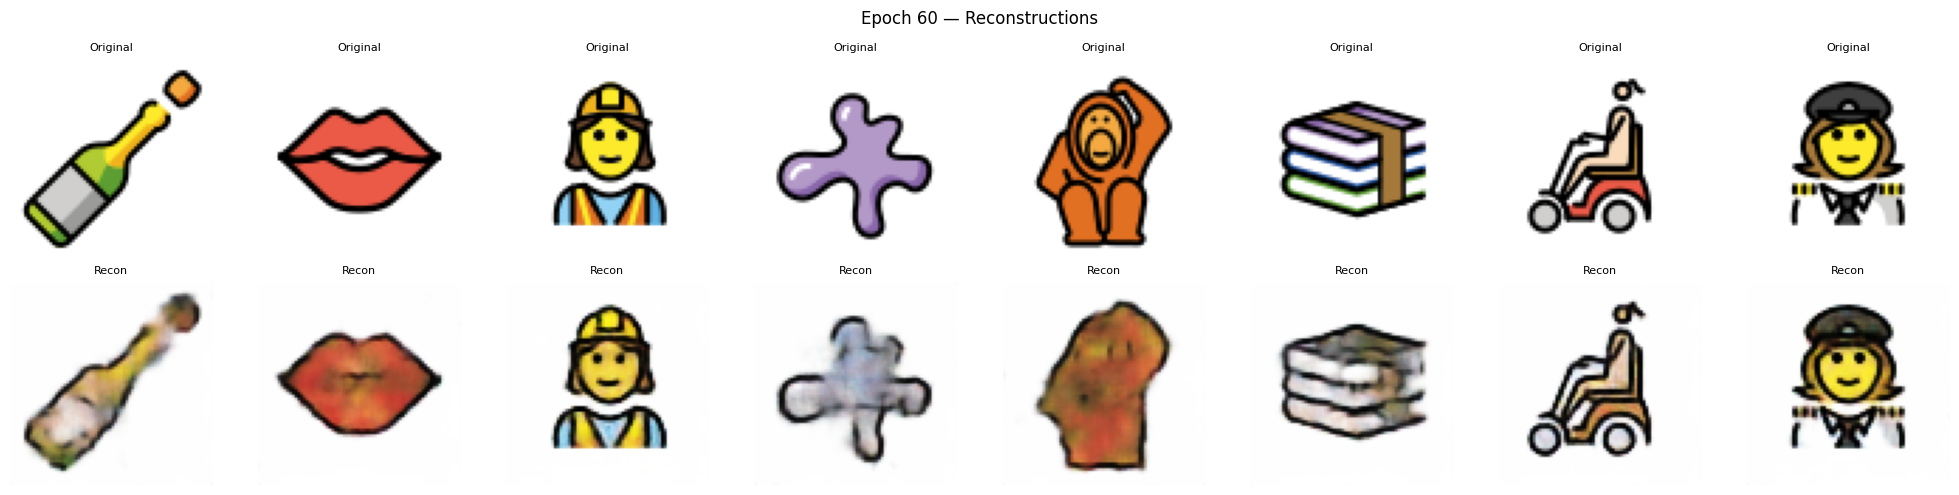

71/71 ━━━━━━━━━━━━━━━━━━━━ 38s 534ms/step - kl_loss: 952.9203 - loss: 146.0870 - recon_loss: 145.6106
Epoch 61/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - kl_loss: 955.5157 - loss: 142.5253 - recon_loss: 142.0476
Epoch 61: loss improved from 146.08702 to 145.80998, saving model to checkpoints/vae_best.weights.h5

Epoch 61: finished saving model to checkpoints/vae_best.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 37s 528ms/step - kl_loss: 953.8508 - loss: 145.8100 - recon_loss: 145.3331
Epoch 62/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - kl_loss: 954.1726 - loss: 140.1000 - recon_loss: 139.6230
Epoch 62: loss improved from 145.80998 to 143.79010, saving model to checkpoints/vae_best.weights.h5

Epoch 62: finished saving model to checkpoints/vae_best.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 37s 521ms/step - kl_loss: 950.9135 - loss: 143.7901 - recon_loss: 143.3146
Epoch 63/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - kl_loss: 951.6706 - loss: 137.1982 - recon_loss: 136.7224
Epoch 63: loss im

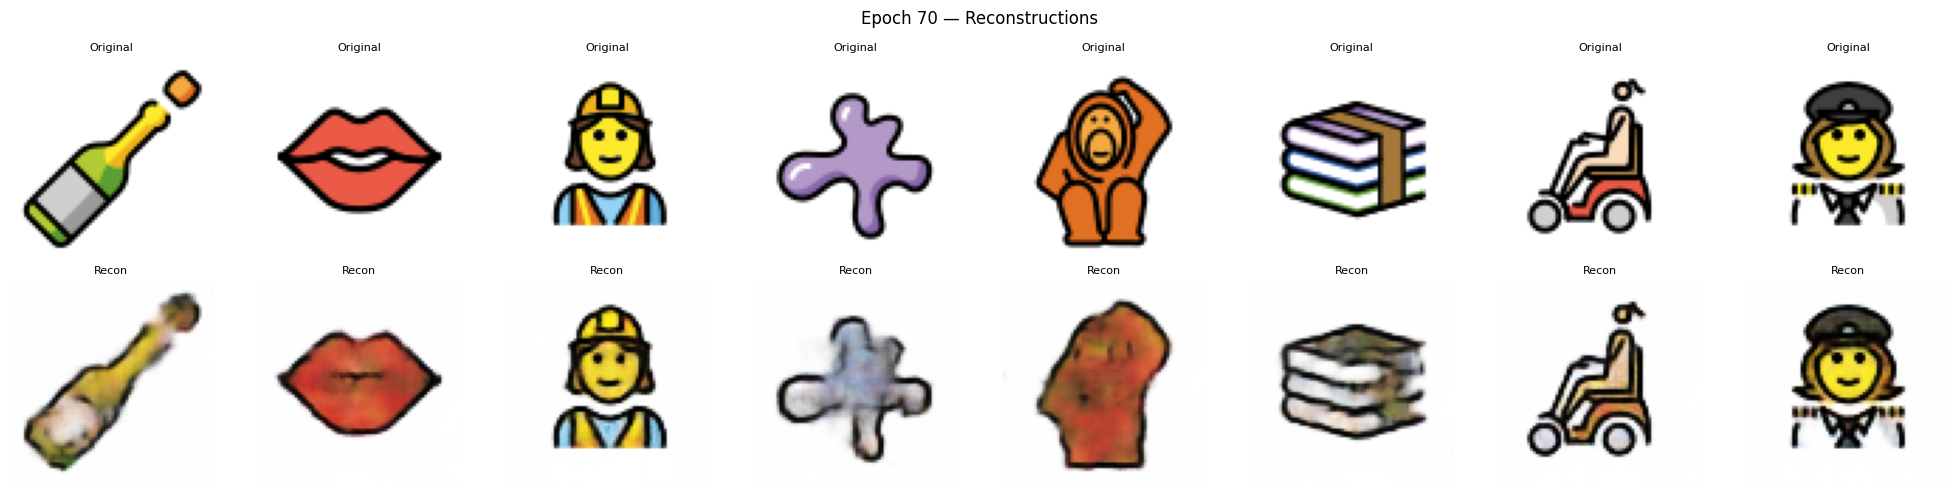

71/71 ━━━━━━━━━━━━━━━━━━━━ 38s 535ms/step - kl_loss: 948.9967 - loss: 133.0071 - recon_loss: 132.5326
Epoch 71/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - kl_loss: 948.2561 - loss: 130.7026 - recon_loss: 130.2285
Epoch 71: loss did not improve from 133.00714
71/71 ━━━━━━━━━━━━━━━━━━━━ 37s 528ms/step - kl_loss: 948.2330 - loss: 133.6246 - recon_loss: 133.1505
Epoch 72/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - kl_loss: 945.3938 - loss: 133.2152 - recon_loss: 132.7425
Epoch 72: loss did not improve from 133.00714
71/71 ━━━━━━━━━━━━━━━━━━━━ 37s 526ms/step - kl_loss: 946.8616 - loss: 133.2887 - recon_loss: 132.8152
Epoch 73/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - kl_loss: 948.2616 - loss: 135.9874 - recon_loss: 135.5133
Epoch 73: loss improved from 133.00714 to 131.54027, saving model to checkpoints/vae_best.weights.h5

Epoch 73: finished saving model to checkpoints/vae_best.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 558ms/step - kl_loss: 946.4058 - loss: 131.5403 - recon_loss: 1

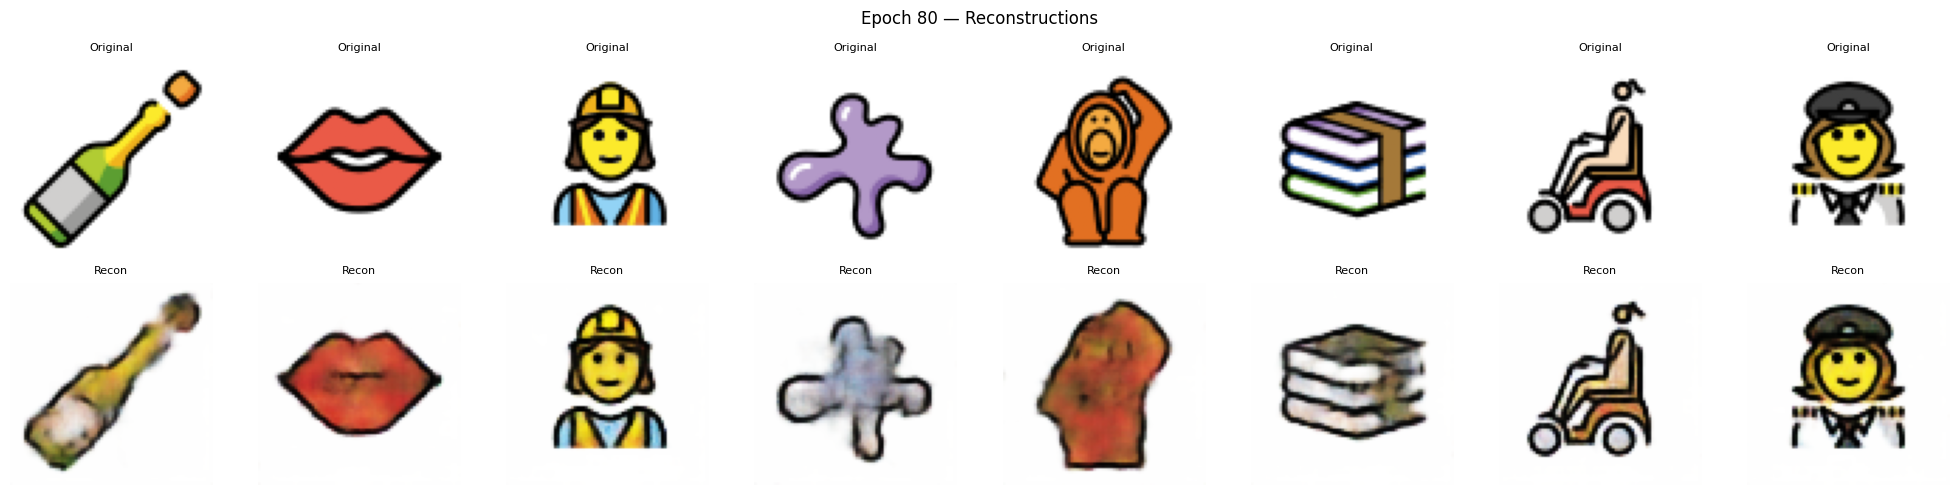

71/71 ━━━━━━━━━━━━━━━━━━━━ 38s 540ms/step - kl_loss: 947.6420 - loss: 130.6055 - recon_loss: 130.1317
Restoring model weights from the end of the best epoch: 80.


In [13]:
# ── 12. Compile & Train ──────────────────────────────────────────────────────

vae = EmojiVAE(encoder, decoder, kl_weight=KL_WEIGHT, name="EmojiVAE")

# Cosine decay LR schedule
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR,
    decay_steps=EPOCHS * len(dataset),
    alpha=1e-5
)

# clipnorm prevents gradient explosion that causes NaN loss
vae.compile(optimizer=keras.optimizers.Adam(lr_schedule, clipnorm=1.0))

# ── Explicitly build the VAE before callbacks try to save it ──────────────
# Pass one real batch through so all sub-model weights are initialized
dummy = next(iter(dataset))          # shape: (batch, 72, 72, 3)
_ = vae(dummy, training=False)       # triggers build on encoder + decoder
print(f"VAE built. Encoder params: {encoder.count_params():,} | Decoder params: {decoder.count_params():,}")

# Sanity check: decoder output must be 72x72x3
test_out = vae(dummy[:2], training=False)
assert test_out.shape == (2, IMG_SIZE, IMG_SIZE, 3), f"Shape mismatch: {test_out.shape}"
print(f"Output shape check passed: {test_out.shape}  ✓")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(CKPT_DIR / "vae_best.weights.h5"),
        save_weights_only=True,
        save_best_only=True,
        monitor="loss",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="loss", patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.TerminateOnNaN(),   # stops immediately if NaN appears
    VisualCallback(val_imgs, every_n=10)
]

history = vae.fit(
    dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

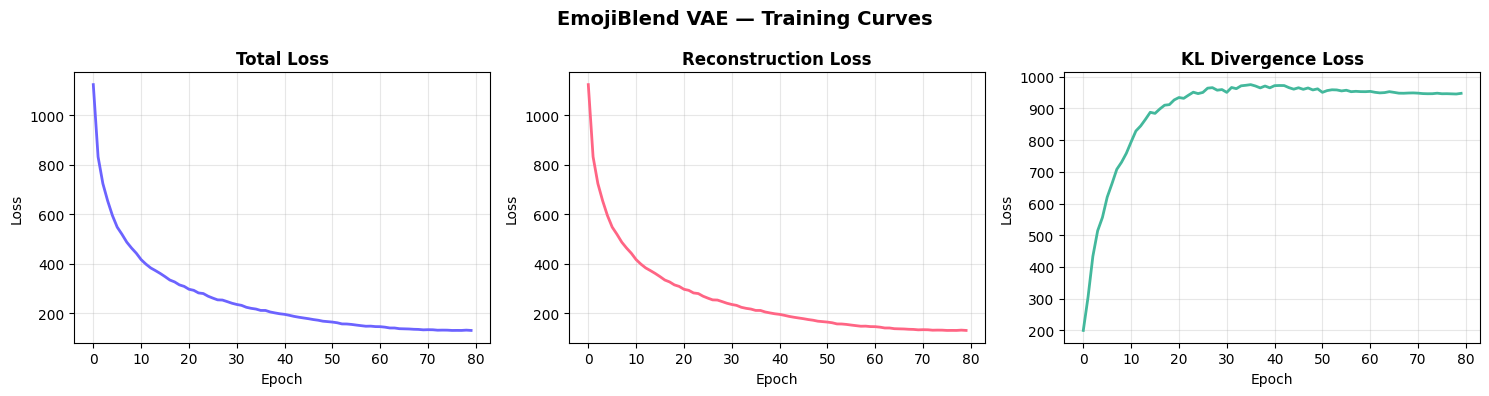

In [19]:
# ── 13. Plot Training Curves ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
keys = ["loss", "recon_loss", "kl_loss"]
titles = ["Total Loss", "Reconstruction Loss", "KL Divergence Loss"]
colors = ["#6C63FF", "#FF6584", "#43B89C"]

for ax, k, t, c in zip(axes, keys, titles, colors):
    ax.plot(history.history[k], color=c, linewidth=2)
    ax.set_title(t, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)

plt.suptitle("EmojiBlend VAE — Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()

In [15]:
# ── 14. Save Models ──────────────────────────────────────────────────────────

encoder.save("emoji_encoder.keras")
decoder.save("emoji_decoder.keras")
print("Models saved: emoji_encoder.keras, emoji_decoder.keras")

Models saved: emoji_encoder.keras, emoji_decoder.keras


In [16]:
# ── 15. Build Emoji Index (for the Streamlit App) ────────────────────────────
# Maps unicode hex → PIL image array, for use in the demo

import json

# Download the OpenMoji metadata JSON
META_URL = "https://raw.githubusercontent.com/hfg-gmuend/openmoji/master/data/openmoji.json"
meta_resp = requests.get(META_URL)
meta = meta_resp.json()

# Build a curated index: emoji char → {hexcode, annotation, group}
emoji_index = []
for entry in meta:
    hexcode    = entry.get("hexcode", "")
    annotation = entry.get("annotation", "")
    group      = entry.get("group", "")
    emoji_char = entry.get("emoji", "")
    # Only include if the PNG exists in our downloaded set
    if hexcode in emoji_lookup and emoji_char:
        emoji_index.append({
            "hexcode": hexcode,
            "emoji": emoji_char,
            "annotation": annotation,
            "group": group
        })

with open("emoji_index.json", "w", encoding="utf-8") as f:
    json.dump(emoji_index, f, ensure_ascii=False, indent=2)

print(f"Emoji index built: {len(emoji_index)} entries → emoji_index.json")

Emoji index built: 4495 entries → emoji_index.json


Blending: 1F647-1F3FC-200D-2640-FE0F  +  1F469-200D-1F466


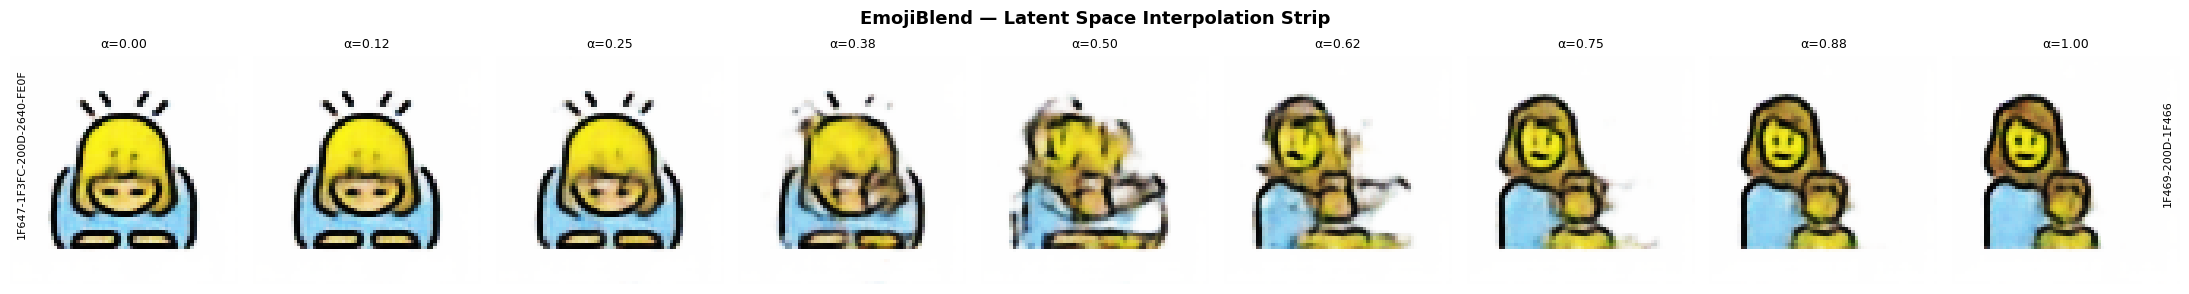

Saved: interpolation_demo.png


In [17]:
# ── 16. Latent Space Interpolation Demo ──────────────────────────────────────
# The CORE feature: blend two emojis at different ratios

def encode_emoji(path):
    img = load_emoji(path)
    img_batch = np.expand_dims(img, 0)
    z_mean, z_log_var, _ = encoder.predict(img_batch, verbose=0)
    return z_mean[0]   # Use mean for deterministic encoding

def blend_emojis(path_a, path_b, steps=9):
    """Interpolate between two emojis in latent space."""
    z_a = encode_emoji(path_a)
    z_b = encode_emoji(path_b)

    alphas = np.linspace(0, 1, steps)
    blended = []
    for alpha in alphas:
        z_blend = (1 - alpha) * z_a + alpha * z_b
        out = decoder.predict(np.expand_dims(z_blend, 0), verbose=0)[0]
        blended.append(np.clip(out, 0, 1))
    return blended, alphas

# Example: pick two emojis from the dataset
sample_paths = list(emoji_lookup.values())
np.random.seed(42)
path_a = np.random.choice(sample_paths)
path_b = np.random.choice(sample_paths)

print(f"Blending: {path_a.stem}  +  {path_b.stem}")
blended_imgs, alphas = blend_emojis(path_a, path_b, steps=9)

# Visualize interpolation strip
fig, axes = plt.subplots(1, 9, figsize=(22, 3))
for ax, img, alpha in zip(axes, blended_imgs, alphas):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"α={alpha:.2f}", fontsize=9)

fig.text(0.01, 0.5, path_a.stem, va='center', fontsize=8, rotation=90)
fig.text(0.99, 0.5, path_b.stem, va='center', fontsize=8, rotation=90, ha='right')
plt.suptitle("EmojiBlend — Latent Space Interpolation Strip", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("interpolation_demo.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved: interpolation_demo.png")

/Users/lorrainequezada/fakemon-vae/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/lorrainequezada/fakemon-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


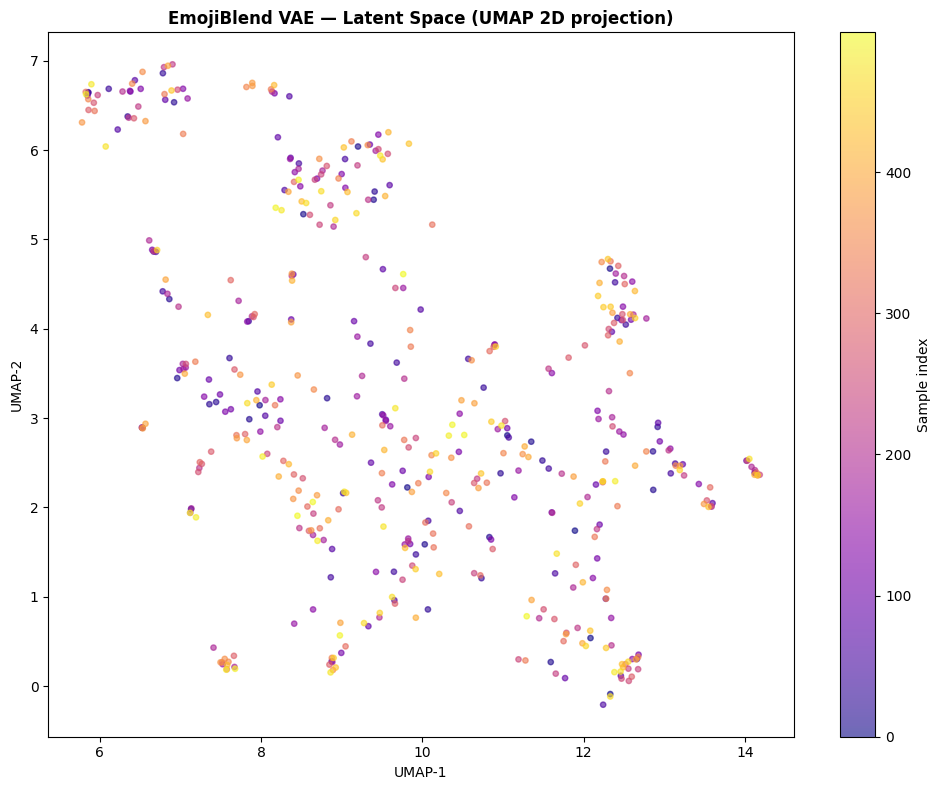

In [18]:
# ── 17. Latent Space 2D Visualization (UMAP) ─────────────────────────────────
!pip install -q umap-learn

import umap

# Encode subset of emojis
N_VIZ = 500
idxs  = np.random.choice(len(images), N_VIZ, replace=False)
batch = images[idxs]
z_means, _, _ = encoder.predict(batch, verbose=0)

reducer   = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(z_means)

plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], s=15, alpha=0.6, c=np.arange(N_VIZ), cmap="plasma")
plt.title("EmojiBlend VAE — Latent Space (UMAP 2D projection)", fontweight="bold")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label="Sample index")
plt.tight_layout()
plt.savefig("latent_space_umap.png", dpi=120)
plt.show()

## ✅ Training Complete!

**Files generated:**
- `emoji_encoder.keras` — Trained encoder model
- `emoji_decoder.keras` — Trained decoder model  
- `emoji_index.json` — Emoji metadata for the Streamlit demo
- `training_curves.png` — Loss curves
- `interpolation_demo.png` — Sample blend strip
- `latent_space_umap.png` — Latent space visualization

**Next step:** Run the Streamlit demo app (`app.py`) — point it to your saved models!